## Gradient Boosting Classification

In [1]:
# import all the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('Travel.csv')

In [3]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [4]:
# handling missing values

#Age
df.Age.fillna(df.Age.median(), inplace=True)

#TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

#DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

#PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

#NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

C:\Users\om_da\AppData\Local\Temp\ipykernel_13676\2043439882.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.median(), inplace=True)
C:\Users\om_da\AppData\Local\Temp\ipykernel_13676\2043439882.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [5]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [6]:
print(df['Gender'].value_counts())
print(df['MaritalStatus'].value_counts())
print(df['TypeofContact'].value_counts())

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64
MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64
TypeofContact
Self Enquiry       3469
Company Invited    1419
Name: count, dtype: int64


In [7]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [8]:
df.drop(columns=['CustomerID'], axis=1, inplace=True)

In [9]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
# create a new feature for total number of visiting

df['TotalVisits'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [11]:
# train test split

from sklearn.model_selection import train_test_split

In [12]:
x = df.drop(columns=['ProdTaken'], axis=1)
y = df['ProdTaken']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

In [15]:
# apply encoding to categorical features

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [16]:
cat_features = x.select_dtypes(include='object').columns
num_features = x.select_dtypes(exclude='object').columns

In [17]:
one_hot_encoder = OneHotEncoder(drop='first')
scaler = StandardScaler()

In [18]:
preprocessor = ColumnTransformer(
    transformers = [
        ('onehot', one_hot_encoder, cat_features),
        ('scaler', scaler, num_features)
    ]
)

In [19]:
x_train = preprocessor.fit_transform(x_train)

In [20]:
x_test = preprocessor.transform(x_test)

## Gradient Boosting Classification Training

In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score

In [24]:
models = {
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost Classifier': AdaBoostClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
}

In [25]:
def model_score(true, predict):
    accuracy = accuracy_score(true, predict)
    precision = precision_score(true, predict)
    recall = recall_score(true, predict)
    f1 = f1_score(true, predict)
    roc = roc_auc_score(true, predict)

    return accuracy, precision, recall, f1, roc

In [26]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train)

    # predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # evaluate the model
    train_acc, train_prec, train_recall, train_f1, train_roc = model_score(y_train, y_train_pred)
    test_acc, test_prec, test_recall, test_f1, test_roc = model_score(y_test, y_test_pred)

    print(list(models.keys())[i])
    print('Performace on Train Data')
    print(f'Accuracy Score: {train_acc:.4f}')
    print(f'Precision: {train_prec:.4f}')
    print(f'Recall Score: {train_recall:.4f}')
    print(f'F1 Score: {train_f1:.4f}')
    print(f'ROC AUC Score: {train_roc:.4f}')
    print('Performance on Test Data')
    print(f'Accuracy Score: {test_acc:.4f}')
    print(f'Precision: {test_prec:.4f}')
    print(f'Recall Score: {test_recall:.4f}')
    print(f'F1 Score: {test_f1:.4f}')
    print(f'ROC AUC Score: {test_roc:.4f}')
    print('*'*35)
    print('\n')

Random Forest
Performace on Train Data
Accuracy Score: 1.0000
Precision: 1.0000
Recall Score: 1.0000
F1 Score: 1.0000
ROC AUC Score: 1.0000
Performance on Test Data
Accuracy Score: 0.9233
Precision: 0.9462
Recall Score: 0.6440
F1 Score: 0.7664
ROC AUC Score: 0.8175
***********************************


Gradient Boosting
Performace on Train Data
Accuracy Score: 0.8939
Precision: 0.8756
Recall Score: 0.5021
F1 Score: 0.6382
ROC AUC Score: 0.7429
Performance on Test Data
Accuracy Score: 0.8589
Precision: 0.7732
Recall Score: 0.3927
F1 Score: 0.5208
ROC AUC Score: 0.6824
***********************************


AdaBoost Classifier
Performace on Train Data
Accuracy Score: 0.8478
Precision: 0.7815
Recall Score: 0.2551
F1 Score: 0.3847
ROC AUC Score: 0.6194
Performance on Test Data
Accuracy Score: 0.8354
Precision: 0.7500
Recall Score: 0.2356
F1 Score: 0.3586
ROC AUC Score: 0.6083
***********************************


Decision Tree
Performace on Train Data
Accuracy Score: 1.0000
Precision: 1.000

In [27]:
## Hyperparameter Training
rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000]
}
gradient_params = {
    "loss": ['log_loss','deviance','exponential'],
    "criterion": ['friedman_mse','squared_error','mse'],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500],
    "max_depth": [5, 8, 15, None, 10]
}

In [30]:
# randomsearchCV models

models = [
    ('Random Forest', RandomForestClassifier(), rf_params),
    ('Gradient Bosoting', GradientBoostingClassifier(), gradient_params)
]

In [31]:
from sklearn.model_selection import RandomizedSearchCV

In [33]:
model_params = {}

for name, model, params in models:
    random = RandomizedSearchCV(estimator=model, param_distributions=params, verbose=2, n_iter=100, cv=3, n_jobs=-1)
    random.fit(x_train, y_train)

    model_params[name] = random.best_params_

for model_name in model_params:
    print(f'Best Parameters for {model_name}')
    print(model_params[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits


d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
81 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\s

Fitting 3 folds for each of 100 candidates, totalling 300 fits


d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
180 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
39 fits failed with the following error:
Traceback (most recent call last):
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "d:\DS, ML, DL, NLP\Machine Learning\venv\Lib\

Best Parameters for Random Forest
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}
Best Parameters for Gradient Bosoting
{'n_estimators': 200, 'min_samples_split': 20, 'max_depth': 15, 'loss': 'log_loss', 'criterion': 'friedman_mse'}


In [36]:
tuned_models = {
    'Random Forest': RandomForestClassifier(n_estimators=1000, min_samples_split=2, max_features=8, max_depth=None),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, min_samples_split=20, max_depth=15, loss='log_loss', criterion='friedman_mse')
}

In [37]:
for i in range(len(list(tuned_models))):
    model = list(tuned_models.values())[i]
    model.fit(x_train, y_train)

    # predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # evaluate the model
    train_acc, train_prec, train_recall, train_f1, train_roc = model_score(y_train, y_train_pred)
    test_acc, test_prec, test_recall, test_f1, test_roc = model_score(y_test, y_test_pred)

    print(list(tuned_models.keys())[i])
    print('Performace on Train Data')
    print(f'Accuracy Score: {train_acc:.4f}')
    print(f'Precision: {train_prec:.4f}')
    print(f'Recall Score: {train_recall:.4f}')
    print(f'F1 Score: {train_f1:.4f}')
    print(f'ROC AUC Score: {train_roc:.4f}')
    print('Performance on Test Data')
    print(f'Accuracy Score: {test_acc:.4f}')
    print(f'Precision: {test_prec:.4f}')
    print(f'Recall Score: {test_recall:.4f}')
    print(f'F1 Score: {test_f1:.4f}')
    print(f'ROC AUC Score: {test_roc:.4f}')
    print('*'*35)
    print('\n')

Random Forest
Performace on Train Data
Accuracy Score: 1.0000
Precision: 1.0000
Recall Score: 1.0000
F1 Score: 1.0000
ROC AUC Score: 1.0000
Performance on Test Data
Accuracy Score: 0.9387
Precision: 0.9712
Recall Score: 0.7068
F1 Score: 0.8182
ROC AUC Score: 0.8509
***********************************


Gradient Boosting
Performace on Train Data
Accuracy Score: 1.0000
Precision: 1.0000
Recall Score: 1.0000
F1 Score: 1.0000
ROC AUC Score: 1.0000
Performance on Test Data
Accuracy Score: 0.9601
Precision: 0.9750
Recall Score: 0.8168
F1 Score: 0.8889
ROC AUC Score: 0.9058
***********************************




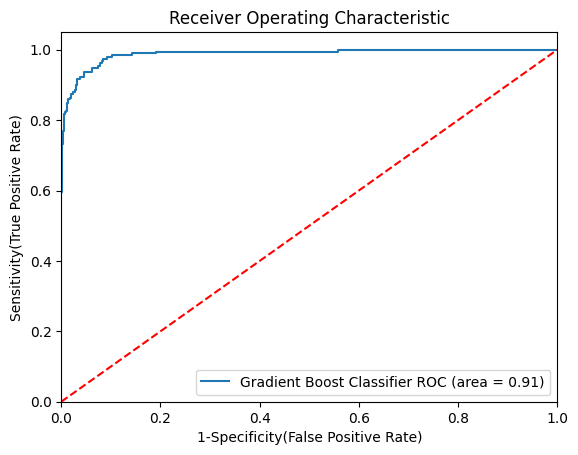

In [38]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Gradient Boost Classifier',
    'model':GradientBoostingClassifier(n_estimators=200, min_samples_split=20, max_depth=15, loss='log_loss', criterion='friedman_mse'),
    'auc':  0.9058
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 